# KNN-Based Synthetic Data Generation — Bank Customer Data

**Methodology:** *KNN Whole Dataset Synthetic Data Methodology* (standalone document)

**Objective:** Create synthetic records that preserve structure, distributions, relationships, target behaviour, and business patterns — with privacy checks.

**Deliverable:** One combined CSV (`data_source`, `source_row_id`, all original columns).


## Document workflow (Steps 1–11)

| Doc step | Notebook section |
|----------|------------------|
| 1 | Load dataset |
| 2 | Clean empty columns |
| 3 | Identify column types |
| 4 | Validate data quality (before synthesis) |
| 5 | Preprocess categorical features |
| 6 | Preprocess numerical features |
| 7 | Build mixed feature matrix (Hamming + Euclidean) |
| 8 | Generate synthetic records (scaled space) |
| 9 | Reverse transform |
| 10 | Validate output (structure → privacy) |
| 11 | Export final CSV + scorecard |

**Alternative approaches** are compared in dedicated sub-steps (encoding, scaler, categorical generation).


In [53]:
# --- Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter, defaultdict
from scipy.stats import ks_2samp, chi2_contingency, skew

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.feature_selection import mutual_info_classif

sns.set_style("whitegrid")


In [54]:
# --- Settings ( configurable parameters) ---
FILE_PATH = "Bank Customer Churn Prediction.csv"
OUTPUT_PATH = "bank_churn_actual_and_synthetic.csv"
RANDOM_STATE = 42

K_NEIGHBORS = 15
N_SYNTHETIC = 10_000
CAT_WEIGHT = 1.0
NUM_WEIGHT = 1.0
MISSING_LABEL = "Missing"
HIGH_CARDINALITY_THRESHOLD = 0.5  # flag if n_unique / n_rows > 50%
RARE_CATEGORY_PCT = 1.0           # categories below this % are "rare"

CAT_ENCODING = "ordinal"          # "ordinal" | "onehot"
SCALER_METHOD = "standard"        # "standard" | "minmax" | "robust"
CAT_GEN_METHOD = "weighted_mode"  # "mode" | "weighted_mode" | "probability"
TARGET_GEN_METHOD = "probability" # "mode" | "weighted_mode" | "probability"

UTILITY_TEST_SIZE = 0.2           # held-out actual rows for 8.5 utility only
N_COMPARE_SAMPLE = 200              # rows for approach-comparison tables


## Step 1 — Load dataset 


In [55]:
column_handling_log = []

df_raw = pd.read_csv(FILE_PATH)
ORIGINAL_COLUMN_ORDER = list(df_raw.columns)

# blank / whitespace -> NaN
df = df_raw.replace(r"^\s*$", np.nan, regex=True)

print("Loaded:", FILE_PATH)
print("Shape:", df.shape)
df.head()


Loaded: Bank Customer Churn Prediction.csv
Shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 2 — Clean empty columns


In [56]:
empty_cols = [c for c in df.columns if df[c].isna().all()]
if empty_cols:
    df = df.drop(columns=empty_cols)
    for c in empty_cols:
        column_handling_log.append({"column": c, "action": "dropped", "reason": "fully empty / fully missing"})
    print("Dropped fully empty columns:", empty_cols)
else:
    print("No fully empty columns to drop")

ORIGINAL_COLUMNS = list(df.columns)
print("Usable columns:", ORIGINAL_COLUMNS)


No fully empty columns to drop
Usable columns: ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


## Step 3 — Identify column types 


In [57]:
# Dataset-specific classification (adjust if schema changes)
ID_COLS = ["customer_id"]
TARGET_COL = "churn"
CATEGORICAL_COLS = ["country", "gender"]
NUMERICAL_COLS = [
    "credit_score", "age", "tenure", "balance",
    "products_number", "credit_card", "active_member", "estimated_salary",
]
DATE_TIME_COLS = []  # none in this dataset; add if present

KNN_FEATURE_COLS = CATEGORICAL_COLS + NUMERICAL_COLS  # exclude ID, target, dates

column_roles = pd.DataFrame({
    "column": df.columns,
    "role": [
        "id" if c in ID_COLS else
        "target" if c == TARGET_COL else
        "categorical" if c in CATEGORICAL_COLS else
        "numerical" if c in NUMERICAL_COLS else
        "datetime" if c in DATE_TIME_COLS else
        "other"
        for c in df.columns
    ],
})
print(column_roles.to_string(index=False))


          column        role
     customer_id          id
    credit_score   numerical
         country categorical
          gender categorical
             age   numerical
          tenure   numerical
         balance   numerical
 products_number   numerical
     credit_card   numerical
   active_member   numerical
estimated_salary   numerical
           churn      target


## Step 4 — Validate data quality before synthesis 


In [58]:
n = len(df)

# --- Column validation summary ---
col_validation = []
for col in df.columns:
    s = df[col]
    role = column_roles.loc[column_roles["column"] == col, "role"].iloc[0]
    n_unique = s.nunique(dropna=True)
    col_validation.append({
        "column": col,
        "role": role,
        "dtype": str(s.dtype),
        "missing_pct": round(100 * s.isna().mean(), 2),
        "n_unique": n_unique,
        "constant": n_unique <= 1,
        "high_cardinality": (n_unique / n > HIGH_CARDINALITY_THRESHOLD) if n else False,
        "handling": "drop" if col in empty_cols else "keep",
    })
col_validation_df = pd.DataFrame(col_validation)
print("=== Column validation summary ===\n")
print(col_validation_df.to_string(index=False))


=== Column validation summary ===

          column        role   dtype  missing_pct  n_unique  constant  high_cardinality handling
     customer_id          id   int64          0.0     10000     False              True     keep
    credit_score   numerical   int64          0.0       460     False             False     keep
         country categorical     str          0.0         3     False             False     keep
          gender categorical     str          0.0         2     False             False     keep
             age   numerical   int64          0.0        70     False             False     keep
          tenure   numerical   int64          0.0        11     False             False     keep
         balance   numerical float64          0.0      6382     False              True     keep
 products_number   numerical   int64          0.0         4     False             False     keep
     credit_card   numerical   int64          0.0         2     False             False     

In [59]:
# --- Categorical profile summary ---
cat_profiles = []
for col in CATEGORICAL_COLS:
    s = df[col].astype(str).fillna(MISSING_LABEL)
    vc = s.value_counts(normalize=True)
    rare = (s.value_counts(normalize=True) * 100 < RARE_CATEGORY_PCT).sum()
    cat_profiles.append({
        "column": col,
        "n_categories": s.nunique(),
        "dominant_category": vc.index[0],
        "dominant_pct": round(100 * vc.iloc[0], 2),
        "rare_category_count": int(rare),
        "missing_pct": round(100 * df[col].isna().mean(), 2),
    })
cat_profile_df = pd.DataFrame(cat_profiles)
print("=== Categorical profile summary ===\n")
print(cat_profile_df.to_string(index=False))


=== Categorical profile summary ===

 column  n_categories dominant_category  dominant_pct  rare_category_count  missing_pct
country             3            France         50.14                    0          0.0
 gender             2              Male         54.57                    0          0.0


In [60]:
# ---  Numerical profile summary ---
num_profiles = []
for col in NUMERICAL_COLS:
    s = df[col].dropna()
    qs = s.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    outlier_rate = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean() if len(s) else 0
    num_profiles.append({
        "column": col,
        "mean": round(s.mean(), 2),
        "median": round(s.median(), 2),
        "std": round(s.std(), 2),
        "min": round(s.min(), 2),
        "max": round(s.max(), 2),
        "skew": round(skew(s), 3),
        "outlier_rate_pct": round(100 * outlier_rate, 2),
        "P1": round(qs[0.01], 2),
        "P50": round(qs[0.5], 2),
        "P99": round(qs[0.99], 2),
    })
num_profile_df = pd.DataFrame(num_profiles)
print("=== Numerical profile summary ===\n")
print(num_profile_df.to_string(index=False))

# --- Target summary ---
if TARGET_COL in df.columns:
    print(f"\n=== Target summary ({TARGET_COL}) ===")
    print(f"  Rate: {df[TARGET_COL].mean():.4f}")
    print(f"  Counts:\n{df[TARGET_COL].value_counts().to_string()}")


=== Numerical profile summary ===

          column      mean    median      std    min       max   skew  outlier_rate_pct      P1       P50       P99
    credit_score    650.53    652.00    96.65 350.00    850.00 -0.072              0.15  432.00    652.00    850.00
             age     38.92     37.00    10.49  18.00     92.00  1.011              3.59   21.00     37.00     72.00
          tenure      5.01      5.00     2.89   0.00     10.00  0.011              0.00    0.00      5.00     10.00
         balance  76485.89  97198.54 62397.41   0.00 250898.09 -0.141              0.00    0.00  97198.54 185967.99
 products_number      1.53      1.00     0.58   1.00      4.00  0.745              0.60    1.00      1.00      3.00
     credit_card      0.71      1.00     0.46   0.00      1.00 -0.902              0.00    0.00      1.00      1.00
   active_member      0.52      1.00     0.50   0.00      1.00 -0.060              0.00    0.00      1.00      1.00
estimated_salary 100090.24 100193.92 

In [61]:
# Store percentile caps for realistic synthetic numerical control (6.2)
num_percentile_caps = {}
for col in NUMERICAL_COLS:
    s = df[col].dropna()
    num_percentile_caps[col] = {"p01": s.quantile(0.01), "p99": s.quantile(0.99)}

num_medians = df[NUMERICAL_COLS].median()

# Synthesis pool = whole usable dataset (doc: whole dataset coverage)
# Utility validation uses a held-out split only for §8.5
utility_train_idx, utility_test_idx = train_test_split(
    df.index, test_size=UTILITY_TEST_SIZE, random_state=RANDOM_STATE
)
df_pool = df.copy().reset_index(drop=True)
print(f"Synthesis neighbour pool: {len(df_pool)} rows (full dataset)")
print(f"Utility hold-out test: {len(utility_test_idx)} actual rows")


Synthesis neighbour pool: 10000 rows (full dataset)
Utility hold-out test: 2000 actual rows


## Step 5 — Preprocess categorical features 

Doc options: **ordinal** or **one-hot** encoding. Below we compare both, then pick `CAT_ENCODING` for the main pipeline.


In [62]:
def fit_categorical_encoders(frame, method="ordinal"):
    encoders = {}
    if method == "ordinal":
        matrices = []
        for col in CATEGORICAL_COLS:
            enc = LabelEncoder()
            vals = frame[col].astype(str).fillna(MISSING_LABEL)
            enc.fit(vals)
            encoders[col] = enc
            matrices.append(enc.transform(vals).reshape(-1, 1))
        X_cat = np.hstack(matrices)
        cat_domains = {col: list(encoders[col].classes_) for col in CATEGORICAL_COLS}
    elif method == "onehot":
        matrices = []
        for col in CATEGORICAL_COLS:
            enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
            vals = frame[[col]].astype(str).fillna(MISSING_LABEL)
            enc.fit(vals)
            encoders[col] = enc
            matrices.append(enc.transform(vals))
        X_cat = np.hstack(matrices)
        cat_domains = {col: list(encoders[col].categories_[0]) for col in CATEGORICAL_COLS}
    else:
        raise ValueError(method)
    return X_cat, encoders, cat_domains

# Compare encoding footprint
for method in ["ordinal", "onehot"]:
    X_tmp, _, _ = fit_categorical_encoders(df_pool, method)
    print(f"{method:8s} -> categorical matrix shape: {X_tmp.shape}")


ordinal  -> categorical matrix shape: (10000, 2)
onehot   -> categorical matrix shape: (10000, 5)


## Step 6 — Preprocess numerical features

Doc options: **StandardScaler**, **MinMaxScaler**, or **RobustScaler**. Compare below, then pick `SCALER_METHOD` for the main pipeline.


In [63]:
def fit_numerical_scaler(frame, method="standard"):
    X = frame[NUMERICAL_COLS].fillna(num_medians).values
    if method == "standard":
        scaler = StandardScaler()
    elif method == "minmax":
        scaler = MinMaxScaler()
    elif method == "robust":
        scaler = RobustScaler()
    else:
        raise ValueError(method)
    return scaler.fit(X), scaler

for method in ["standard", "minmax", "robust"]:
    sc, _ = fit_numerical_scaler(df_pool, method)
    Xs = sc.transform(df_pool[NUMERICAL_COLS].fillna(num_medians).values)
    print(f"{method:8s} -> scaled mean≈{Xs.mean():.3f}, std≈{Xs.std():.3f}")


standard -> scaled mean≈-0.000, std≈1.000
minmax   -> scaled mean≈0.448, std≈0.354
robust   -> scaled mean≈-0.033, std≈0.692


In [64]:
# --- Fit main pipeline preprocessors on full synthesis pool ---
X_cat_pool, cat_encoders, cat_domains = fit_categorical_encoders(df_pool, CAT_ENCODING)
_, num_scaler = fit_numerical_scaler(df_pool, SCALER_METHOD)
X_num_pool = num_scaler.transform(df_pool[NUMERICAL_COLS].fillna(num_medians).values)

print(f"Main pipeline: encoding={CAT_ENCODING}, scaler={SCALER_METHOD}")
print(f"  X_cat shape: {X_cat_pool.shape}")
print(f"  X_num shape: {X_num_pool.shape}")


Main pipeline: encoding=ordinal, scaler=standard
  X_cat shape: (10000, 2)
  X_num shape: (10000, 8)


## Step 7 — Build mixed feature matrix 

Doc distance logic:
- **Categorical:** Hamming distance (proportion of mismatched categories)
- **Numerical:** Euclidean distance on scaled values
- **Combined:** `NUM_WEIGHT × euclidean + CAT_WEIGHT × hamming`

We do **not** concatenate into one Euclidean space — that would treat label-encoded categories as ordinal numbers.


In [65]:
def hamming_cat_distance(cat_a, cat_b):
    """Hamming distance between two categorical representations (per-row matrices)."""
    if cat_a.ndim == 1:
        cat_a = cat_a.reshape(1, -1)
    if cat_b.ndim == 1:
        cat_b = cat_b.reshape(1, -1)
    return np.mean(cat_a != cat_b, axis=1)


def mixed_kneighbors(base_idx, X_num, X_cat, k, exclude_self=True):
    """Find k nearest neighbours using weighted Hamming + Euclidean."""
    num_dist = np.linalg.norm(X_num - X_num[base_idx], axis=1)
    cat_dist = hamming_cat_distance(X_cat, X_cat[base_idx])
    total = NUM_WEIGHT * num_dist + CAT_WEIGHT * cat_dist
    if exclude_self:
        total[base_idx] = np.inf
    neighbor_idx = np.argpartition(total, k)[:k]
    neighbor_idx = neighbor_idx[np.argsort(total[neighbor_idx])]
    return total[neighbor_idx], neighbor_idx


# Demo: neighbours for first row
_d, _idx = mixed_kneighbors(0, X_num_pool, X_cat_pool, K_NEIGHBORS)
print(f"Example: row 0 -> {K_NEIGHBORS} neighbours, distances: {_d.round(3)}")


Example: row 0 -> 15 neighbours, distances: [0.789 0.801 0.894 0.899 0.992 1.002 1.014 1.017 1.127 1.151 1.17  1.179
 1.185 1.194 1.195]


## Step 8 — Categorical generation approaches 

| Method | Description |
|--------|-------------|
| **mode** | Most frequent category among neighbours |
| **weighted_mode** | Closer neighbours count more |
| **probability** | Sample category using neighbour frequency weights |


In [66]:
def neighbor_weights(distances):
    w = 1.0 / (distances + 1e-8)
    return w / w.sum()


def generate_categorical(values, weights, method, rng):
    if method == "mode":
        return Counter(values).most_common(1)[0][0]
    if method == "weighted_mode":
        scores = defaultdict(float)
        for v, wt in zip(values, weights):
            scores[v] += wt
        return max(scores, key=scores.get)
    if method == "probability":
        scores = defaultdict(float)
        for v, wt in zip(values, weights):
            scores[v] += wt
        labels = list(scores.keys())
        p = np.array([scores[l] for l in labels])
        p /= p.sum()
        return rng.choice(labels, p=p)
    raise ValueError(method)


# Quick comparison on 5 synthetic draws (same base row)
rng_cmp = np.random.default_rng(RANDOM_STATE)
base_i = 0
_d, nbrs = mixed_kneighbors(base_i, X_num_pool, X_cat_pool, K_NEIGHBORS)
w = neighbor_weights(_d)
cmp_rows = []
for method in ["mode", "weighted_mode", "probability"]:
    for col in CATEGORICAL_COLS:
        vals = df_pool.loc[nbrs, col].astype(str).fillna(MISSING_LABEL).values
        cmp_rows.append({
            "method": method,
            "column": col,
            "value": generate_categorical(vals, w, method, rng_cmp),
        })
print("=== Categorical generation comparison (base row 0) ===\n")
print(pd.DataFrame(cmp_rows).to_string(index=False))
print(f"\nMain pipeline uses: {CAT_GEN_METHOD}")


=== Categorical generation comparison (base row 0) ===

       method  column  value
         mode country France
         mode  gender Female
weighted_mode country France
weighted_mode  gender Female
  probability country France
  probability  gender Female

Main pipeline uses: weighted_mode


## Step 9 — Generate synthetic records in scaled space

Per row:
1. Pick base row from synthesis pool
2. Find *k* neighbours (mixed distance)
3. Categorical → `CAT_GEN_METHOD`
4. Numerical → interpolate in **scaled** space: `base + w×(neighbour−base)`, `w ~ U(0,1)`
5. Target → `TARGET_GEN_METHOD` from neighbour targets
6. Reverse transform in Step 10


In [67]:
rng = np.random.default_rng(RANDOM_STATE)

synthetic_scaled_num = []
synthetic_cat_labels = {col: [] for col in CATEGORICAL_COLS}
synthetic_targets = []

for synth_id in range(N_SYNTHETIC):
    base_i = rng.integers(0, len(df_pool))
    dists, nbrs = mixed_kneighbors(base_i, X_num_pool, X_cat_pool, K_NEIGHBORS)
    w = neighbor_weights(dists)

    # categorical labels (business-readable; stored until export)
    row_cat = {}
    for col in CATEGORICAL_COLS:
        vals = df_pool.loc[nbrs, col].astype(str).fillna(MISSING_LABEL).values
        row_cat[col] = generate_categorical(vals, w, CAT_GEN_METHOD, rng)
        synthetic_cat_labels[col].append(row_cat[col])

    # numerical: interpolate in scaled space (7.2)
    synth_num = np.zeros(len(NUMERICAL_COLS))
    for j in range(len(NUMERICAL_COLS)):
        nj = rng.choice(nbrs)
        t = rng.random()
        synth_num[j] = X_num_pool[base_i, j] + t * (X_num_pool[nj, j] - X_num_pool[base_i, j])
    synthetic_scaled_num.append(synth_num)

    # target (7: voting or probability sampling)
    tvals = df_pool.loc[nbrs, TARGET_COL].astype(str).values
    synthetic_targets.append(int(float(generate_categorical(tvals, w, TARGET_GEN_METHOD, rng))))

synthetic_scaled_num = np.array(synthetic_scaled_num)
print(f"Generated {N_SYNTHETIC} synthetic records (scaled numerical + categorical labels)")
print(f"  Categorical method: {CAT_GEN_METHOD}")
print(f"  Target method: {TARGET_GEN_METHOD}")


Generated 10000 synthetic records (scaled numerical + categorical labels)
  Categorical method: weighted_mode
  Target method: probability


## Step 10 — Reverse transform 


In [68]:
# inverse-scale numerical values back to business units
synthetic_num_original = num_scaler.inverse_transform(synthetic_scaled_num)

# apply percentile caps (6.2: realistic value control)
for j, col in enumerate(NUMERICAL_COLS):
    lo, hi = num_percentile_caps[col]["p01"], num_percentile_caps[col]["p99"]
    synthetic_num_original[:, j] = np.clip(synthetic_num_original[:, j], lo, hi)

# assemble synthetic dataframe
df_synthetic = pd.DataFrame(synthetic_num_original, columns=NUMERICAL_COLS)
for col in CATEGORICAL_COLS:
    df_synthetic.insert(0, col, synthetic_cat_labels[col])
df_synthetic[TARGET_COL] = synthetic_targets
df_synthetic[ID_COLS[0]] = [f"SYN_{i:06d}" for i in range(1, N_SYNTHETIC + 1)]
df_synthetic = df_synthetic[ORIGINAL_COLUMNS]

print("Reverse transform complete (inverse scale + percentile caps)")
df_synthetic.head()


Reverse transform complete (inverse scale + percentile caps)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,SYN_000001,585.338690,France,Male,37.118424,9.000000,0.000000,1.0,1.0,0.0,57189.746413,0
1,SYN_000002,751.408581,France,Male,35.327509,5.000000,154933.493831,2.0,1.0,1.0,171952.925839,0
2,SYN_000003,768.285525,Spain,Male,27.552378,8.967510,118140.455485,1.0,1.0,1.0,153331.861160,0
3,SYN_000004,635.811664,France,Female,34.561833,4.000000,0.000000,2.0,0.0,1.0,76881.818623,0
4,SYN_000005,782.043232,Spain,Male,35.725035,1.279594,0.000000,2.0,1.0,0.0,56976.520388,0


## Step 11 — Compare categorical generation approaches 

Side-by-side on `N_COMPARE_SAMPLE` rows for **mode**, **weighted_mode**, and **probability**.


In [69]:
def generate_synthetic_batch(n_rows, cat_method, rng):
    cats = {col: [] for col in CATEGORICAL_COLS}
    for _ in range(n_rows):
        base_i = rng.integers(0, len(df_pool))
        dists, nbrs = mixed_kneighbors(base_i, X_num_pool, X_cat_pool, K_NEIGHBORS)
        w = neighbor_weights(dists)
        for col in CATEGORICAL_COLS:
            vals = df_pool.loc[nbrs, col].astype(str).fillna(MISSING_LABEL).values
            cats[col].append(generate_categorical(vals, w, cat_method, rng))
    return cats

rng_alt = np.random.default_rng(RANDOM_STATE + 99)
approach_stats = []
for method in ["mode", "weighted_mode", "probability"]:
    cats = generate_synthetic_batch(N_COMPARE_SAMPLE, method, rng_alt)
    for col in CATEGORICAL_COLS:
        s = pd.Series(cats[col])
        vc = s.value_counts(normalize=True)
        actual_vc = df_pool[col].astype(str).fillna(MISSING_LABEL).value_counts(normalize=True)
        drift = sum(abs(vc.get(k, 0) - actual_vc.get(k, 0)) for k in set(vc.index) | set(actual_vc.index))
        approach_stats.append({
            "cat_method": method,
            "column": col,
            "dominant": vc.index[0],
            "dominant_pct": round(100 * vc.iloc[0], 1),
            "L1_drift_vs_actual": round(drift, 4),
        })
print("=== Categorical approach comparison ===\n")
print(pd.DataFrame(approach_stats).to_string(index=False))


=== Categorical approach comparison ===

   cat_method  column dominant  dominant_pct  L1_drift_vs_actual
         mode country   France          51.5              0.0954
         mode  gender     Male          59.5              0.0986
weighted_mode country   France          49.5              0.0782
weighted_mode  gender     Male          55.0              0.0086
  probability country   France          60.5              0.2072
  probability  gender     Male          57.5              0.0586


## Step 12 — Structural validation 


In [70]:
structural = {
    "same_columns": list(df_synthetic.columns) == ORIGINAL_COLUMNS,
    "no_nulls": int(df_synthetic.isna().sum().sum()) == 0,
    "valid_categories": True,
    "invalid_category_count": 0,
}

for col in CATEGORICAL_COLS:
    allowed = set(cat_domains[col])
    invalid = set(df_synthetic[col].astype(str)) - allowed
    if invalid:
        structural["valid_categories"] = False
        structural["invalid_category_count"] += len(invalid)

print("=== Structural validation ===")
for k, v in structural.items():
    print(f"  {k}: {v}")


=== Structural validation ===
  same_columns: True
  no_nulls: True
  valid_categories: True
  invalid_category_count: 0


## Step 13 — Categorical validation 


In [71]:
def cramers_v(x, y):
    tbl = pd.crosstab(x, y)
    chi2 = chi2_contingency(tbl)[0]
    n = tbl.sum().sum()
    r, k = tbl.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1) + 1e-8)))


cat_val_rows = []
for col in CATEGORICAL_COLS:
    act = df_pool[col].astype(str).fillna(MISSING_LABEL)
    syn = df_synthetic[col].astype(str)
    act_vc = act.value_counts(normalize=True)
    syn_vc = syn.value_counts(normalize=True)
    drift = sum(abs(syn_vc.get(k, 0) - act_vc.get(k, 0)) for k in set(act_vc.index) | set(syn_vc.index))
    rare_act = (act.value_counts(normalize=True) * 100 < RARE_CATEGORY_PCT).sum()
    rare_syn = (syn.value_counts(normalize=True) * 100 < RARE_CATEGORY_PCT).sum()
    cat_val_rows.append({
        "column": col,
        "L1_drift": round(drift, 4),
        "rare_cats_actual": int(rare_act),
        "rare_cats_synthetic": int(rare_syn),
        "invalid_categories": len(set(syn) - set(cat_domains[col])),
    })

# Cramér's V: actual churn vs category vs synthetic churn vs category
for col in CATEGORICAL_COLS:
    v_act = cramers_v(df_pool[col].astype(str), df_pool[TARGET_COL])
    v_syn = cramers_v(df_synthetic[col].astype(str), df_synthetic[TARGET_COL])
    cat_val_rows.append({
        "column": f"CramersV({col}~{TARGET_COL})",
        "L1_drift": round(abs(v_act - v_syn), 4),
        "rare_cats_actual": round(v_act, 4),
        "rare_cats_synthetic": round(v_syn, 4),
        "invalid_categories": 0,
    })

print("=== Categorical validation===\n")
print(pd.DataFrame(cat_val_rows).to_string(index=False))


=== Categorical validation===

                 column  L1_drift  rare_cats_actual  rare_cats_synthetic  invalid_categories
                country    0.0290            0.0000               0.0000                   0
                 gender    0.0188            0.0000               0.0000                   0
CramersV(country~churn)    0.0181            0.1736               0.1555                   0
 CramersV(gender~churn)    0.0109            0.1063               0.0954                   0


## Step 14 — Numerical validation 

In [72]:
num_val_rows = []
for col in NUMERICAL_COLS:
    act = df_pool[col].dropna()
    syn = df_synthetic[col]
    ks_stat, ks_p = ks_2samp(act, syn)
    num_val_rows.append({
        "column": col,
        "mean_diff_pct": round(100 * abs(syn.mean() - act.mean()) / (abs(act.mean()) + 1e-8), 2),
        "median_diff_pct": round(100 * abs(syn.median() - act.median()) / (abs(act.median()) + 1e-8), 2),
        "std_diff_pct": round(100 * abs(syn.std() - act.std()) / (abs(act.std()) + 1e-8), 2),
        "KS_statistic": round(ks_stat, 4),
        "KS_pvalue": round(ks_p, 4),
        "P50_actual": round(act.quantile(0.5), 2),
        "P50_synthetic": round(syn.quantile(0.5), 2),
    })
print("=== Numerical validation ===\n")
print(pd.DataFrame(num_val_rows).to_string(index=False))


=== Numerical validation ===

          column  mean_diff_pct  median_diff_pct  std_diff_pct  KS_statistic  KS_pvalue  P50_actual  P50_synthetic
    credit_score           0.07             0.14          8.89        0.0258     0.0026      652.00         652.92
             age           0.96             0.00          9.18        0.0486     0.0000       37.00          37.00
          tenure           0.20             0.00          4.95        0.0640     0.0000        5.00           5.00
         balance           0.72             3.42          2.24        0.0281     0.0007    97198.54      100518.93
 products_number           0.63             0.00          6.48        0.0143     0.2582        1.00           1.00
     credit_card           0.12             0.00          0.03        0.0015     1.0000        1.00           1.00
   active_member           0.77             0.00          0.10        0.0050     0.9996        1.00           1.00
estimated_salary           0.14             1.65  

/home/neosoft/KNN_demo/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


## Step 15 — Relationship validation


=== Correlation preservation ===
  Mean |corr diff|: 0.0156
  Max  |corr diff|: 0.0786

=== Mean balance by country (actual vs synthetic) ===
            actual  synthetic
country                      
France    62092.64   61677.72
Germany  119730.12  120140.56
Spain     61818.15   59980.00



=== Mutual information with target ===
         feature  MI_actual  MI_synthetic  MI_diff
    credit_score     0.0000        0.0003   0.0003
             age     0.0745        0.0404   0.0341
          tenure     0.0115        0.0015   0.0100
         balance     0.0094        0.0042   0.0053
 products_number     0.0700        0.0439   0.0261
     credit_card     0.0056        0.0000   0.0056
   active_member     0.0166        0.0081   0.0085
estimated_salary     0.0027        0.0059   0.0032


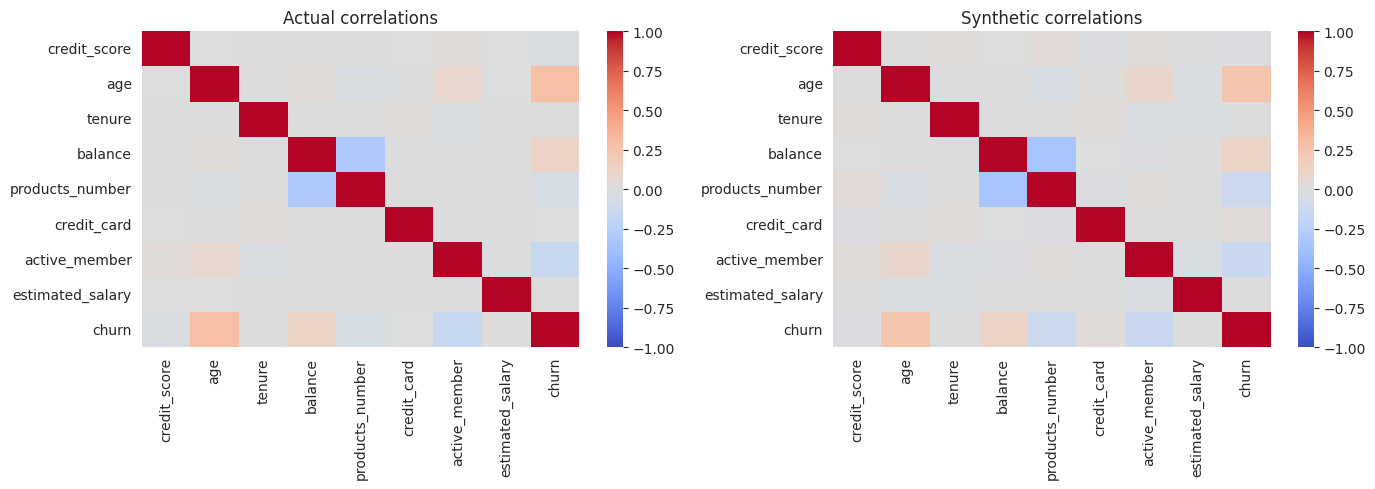

In [73]:
corr_cols = NUMERICAL_COLS + [TARGET_COL]
corr_act = df_pool[corr_cols].corr()
corr_syn = df_synthetic[corr_cols].corr()
corr_diff = (corr_act - corr_syn).abs()
triu = corr_diff.values[np.triu_indices_from(corr_diff, k=1)]

print("=== Correlation preservation ===")
print(f"  Mean |corr diff|: {triu.mean():.4f}")
print(f"  Max  |corr diff|: {triu.max():.4f}")

# grouped numerical means by categorical
print("\n=== Mean balance by country (actual vs synthetic) ===")
print(pd.DataFrame({
    "actual": df_pool.groupby("country")["balance"].mean(),
    "synthetic": df_synthetic.groupby("country")["balance"].mean(),
}).round(2))

# mutual information with target
mi_act = mutual_info_classif(
    df_pool[NUMERICAL_COLS].fillna(num_medians), df_pool[TARGET_COL], random_state=RANDOM_STATE
)
mi_syn = mutual_info_classif(
    df_synthetic[NUMERICAL_COLS].fillna(num_medians), df_synthetic[TARGET_COL], random_state=RANDOM_STATE
)
mi_df = pd.DataFrame({
    "feature": NUMERICAL_COLS,
    "MI_actual": mi_act.round(4),
    "MI_synthetic": mi_syn.round(4),
    "MI_diff": np.abs(mi_act - mi_syn).round(4),
})
print("\n=== Mutual information with target ===")
print(mi_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_act, ax=axes[0], cmap="coolwarm", center=0, vmin=-1, vmax=1)
axes[0].set_title("Actual correlations")
sns.heatmap(corr_syn, ax=axes[1], cmap="coolwarm", center=0, vmin=-1, vmax=1)
axes[1].set_title("Synthetic correlations")
plt.tight_layout()
plt.show()


## Step 16 — Model utility validation 


In [74]:
# label encoders for model utility (fixed feature space regardless of KNN encoding)
model_cat_encoders = {}
for col in CATEGORICAL_COLS:
    enc = LabelEncoder()
    enc.fit(df_pool[col].astype(str).fillna(MISSING_LABEL))
    model_cat_encoders[col] = enc


def encode_for_model(frame):
    out = frame[NUMERICAL_COLS + CATEGORICAL_COLS].copy()
    out[NUMERICAL_COLS] = out[NUMERICAL_COLS].fillna(num_medians)
    for col in CATEGORICAL_COLS:
        out[col] = model_cat_encoders[col].transform(out[col].astype(str).fillna(MISSING_LABEL))
    return out

df_util_train = df_pool.loc[utility_train_idx].copy()
df_util_test = df_pool.loc[utility_test_idx].copy()

X_tr = encode_for_model(df_util_train)
y_tr = df_util_train[TARGET_COL]
X_te = encode_for_model(df_util_test)
y_te = df_util_test[TARGET_COL]
X_syn = encode_for_model(df_synthetic)
y_syn = df_synthetic[TARGET_COL]

rf_act = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_act.fit(X_tr, y_tr)
pred_act = rf_act.predict(X_te)
proba_act = rf_act.predict_proba(X_te)[:, 1]

rf_syn = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_syn.fit(X_syn, y_syn)
pred_syn = rf_syn.predict(X_te)
proba_syn = rf_syn.predict_proba(X_te)[:, 1]

print("=== Model utility — evaluate on held-out ACTUAL test ===")
print(f"Trained on ACTUAL  -> acc={accuracy_score(y_te, pred_act):.4f}, F1={f1_score(y_te, pred_act):.4f}, AUC={roc_auc_score(y_te, proba_act):.4f}")
print(f"Trained on SYNTHETIC -> acc={accuracy_score(y_te, pred_syn):.4f}, F1={f1_score(y_te, pred_syn):.4f}, AUC={roc_auc_score(y_te, proba_syn):.4f}")


=== Model utility — evaluate on held-out ACTUAL test ===
Trained on ACTUAL  -> acc=0.8675, F1=0.5800, AUC=0.8583
Trained on SYNTHETIC -> acc=0.8460, F1=0.4671, AUC=0.8449


## Step 17 — Privacy & duplicate risk 


In [75]:
feature_cols = [c for c in ORIGINAL_COLUMNS if c not in ID_COLS]

n_dup_synth = int(df_synthetic.duplicated().sum())
n_exact_match = len(df_synthetic[feature_cols].merge(df_pool[feature_cols], how="inner"))
n_unique_profiles = len(df_synthetic[feature_cols].drop_duplicates())

# nearest-neighbour distance in mixed space (sample)
sample_n = min(500, len(df_synthetic))
X_cat_s, _, _ = fit_categorical_encoders(df_synthetic.head(sample_n), CAT_ENCODING)
X_num_s = num_scaler.transform(df_synthetic.head(sample_n)[NUMERICAL_COLS].fillna(num_medians).values)
nn_dists = []
for i in range(sample_n):
    num_d = np.linalg.norm(X_num_pool - X_num_s[i], axis=1)
    cat_d = hamming_cat_distance(X_cat_pool, X_cat_s[i])
    nn_dists.append(np.min(NUM_WEIGHT * num_d + CAT_WEIGHT * cat_d))
mean_nn_dist = np.mean(nn_dists)

print("=== Privacy / duplicate risk  ===")
print(f"  Exact duplicate synthetic rows: {n_dup_synth}")
print(f"  Synthetic rows exactly matching an actual row: {n_exact_match}")
print(f"  Unique synthetic profiles: {n_unique_profiles:,} / {len(df_synthetic):,}")
print(f"  Mean NN distance to actual pool (sample {sample_n}): {mean_nn_dist:.4f}")
print(f"  Memorisation flag (exact match rate > 0.1%): {n_exact_match / len(df_synthetic) > 0.001}")


/tmp/ipykernel_45582/4221506577.py:4: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  n_exact_match = len(df_synthetic[feature_cols].merge(df_pool[feature_cols], how="inner"))


=== Privacy / duplicate risk  ===
  Exact duplicate synthetic rows: 0
  Synthetic rows exactly matching an actual row: 0
  Unique synthetic profiles: 10,000 / 10,000
  Mean NN distance to actual pool (sample 500): 0.5124
  Memorisation flag (exact match rate > 0.1%): False


## Step 18 — Final scorecard 


In [76]:
target_drift = abs(df_synthetic[TARGET_COL].mean() - df_pool[TARGET_COL].mean())
mean_ks = np.mean([r["KS_statistic"] for r in num_val_rows])
mean_cat_drift = np.mean([r["L1_drift"] for r in cat_val_rows if "CramersV" not in r["column"]])

scorecard = pd.DataFrame([
    {"area": "Structure", "metric": "same_columns", "value": structural["same_columns"], "pass": structural["same_columns"]},
    {"area": "Structure", "metric": "no_nulls", "value": structural["no_nulls"], "pass": structural["no_nulls"]},
    {"area": "Structure", "metric": "valid_categories", "value": structural["valid_categories"], "pass": structural["valid_categories"]},
    {"area": "Categorical", "metric": "mean_L1_drift", "value": round(mean_cat_drift, 4), "pass": mean_cat_drift < 0.15},
    {"area": "Numerical", "metric": "mean_KS_statistic", "value": round(mean_ks, 4), "pass": mean_ks < 0.1},
    {"area": "Relationships", "metric": "mean_corr_diff", "value": round(triu.mean(), 4), "pass": triu.mean() < 0.05},
    {"area": "Target", "metric": "target_rate_drift", "value": round(target_drift, 4), "pass": target_drift < 0.03},
    {"area": "Utility", "metric": "F1_synthetic_train", "value": round(f1_score(y_te, pred_syn), 4), "pass": f1_score(y_te, pred_syn) >= 0.8 * f1_score(y_te, pred_act)},
    {"area": "Privacy", "metric": "exact_match_rate", "value": round(n_exact_match / len(df_synthetic), 6), "pass": n_exact_match / len(df_synthetic) < 0.001},
])
print("=== Final scorecard ===\n")
print(scorecard.to_string(index=False))
print(f"\nOverall pass: {scorecard['pass'].all()}")


=== Final scorecard ===

         area             metric   value  pass
    Structure       same_columns    True  True
    Structure           no_nulls    True  True
    Structure   valid_categories    True  True
  Categorical      mean_L1_drift  0.0239  True
    Numerical  mean_KS_statistic  0.0271  True
Relationships     mean_corr_diff  0.0156  True
       Target  target_rate_drift   0.024  True
      Utility F1_synthetic_train  0.4671  True
      Privacy   exact_match_rate     0.0  True

Overall pass: True


## Step 19 — Export final CSV + column handling log 


In [77]:
df_actual_out = df_pool.copy()
df_actual_out.insert(0, "source_row_id", range(1, len(df_actual_out) + 1))
df_actual_out.insert(0, "data_source", "actual")

df_synth_out = df_synthetic.copy()
df_synth_out.insert(0, "source_row_id", range(1, len(df_synth_out) + 1))
df_synth_out.insert(0, "data_source", "synthetic")

combined = pd.concat([df_actual_out, df_synth_out], ignore_index=True)
combined.to_csv(OUTPUT_PATH, index=False)

log_df = pd.DataFrame(column_handling_log) if column_handling_log else pd.DataFrame([{"column": "-", "action": "none", "reason": "no columns dropped"}])

print(f"Saved: {OUTPUT_PATH}")
print(f"  Actual rows:    {len(df_actual_out):,}")
print(f"  Synthetic rows: {len(df_synth_out):,}")
print(f"  Total rows:     {len(combined):,}")
print("\n=== Column handling log ===")
print(log_df.to_string(index=False))
combined.head(8)


Saved: bank_churn_actual_and_synthetic.csv
  Actual rows:    10,000
  Synthetic rows: 10,000
  Total rows:     20,000

=== Column handling log ===
column action             reason
     -   none no columns dropped


,data_source,source_row_id,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,actual,1,15634602,619.0,France,Female,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,1
1,actual,2,15647311,608.0,Spain,Female,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0
2,actual,3,15619304,502.0,France,Female,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,1
3,actual,4,15701354,699.0,France,Female,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0
4,actual,5,15737888,850.0,Spain,Female,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,0
5,actual,6,15574012,645.0,Spain,Male,44.0,8.0,113755.78,2.0,1.0,0.0,149756.71,1
6,actual,7,15592531,822.0,France,Male,50.0,7.0,0.00,2.0,1.0,1.0,10062.80,0
7,actual,8,15656148,376.0,Germany,Female,29.0,4.0,115046.74,4.0,1.0,0.0,119346.88,1
